# Лабораторна робота: Базові алгоритми класифікації у Scikit-learn
**Датасет:** Telco Customer Churn (Kaggle)  
**Цільова змінна:** `Churn` (відтік клієнтів: так/ні)

In [ ]:
!pip install -q kagglehub

import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Завантаження та первинний аналіз даних

In [ ]:
# Завантаження датасету з Kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок\n")
print("Колонки:", df.columns.tolist())
print("\nТипи даних:")
print(df.dtypes)
print("\nРозподіл цільової змінної Churn:")
print(df['Churn'].value_counts())
print("\nВідсоткове співвідношення класів:")
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Розмір датасету: 7043 рядків, 21 колонок

Колонки: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Типи даних:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Total

## 2. Попередня обробка даних (Preprocessing)

### Обґрунтування прийнятих рішень:

**Видалення `customerID`:** Ця колонка є унікальним ідентифікатором клієнта. Вона не містить жодної закономірності для моделювання, а алгоритми машинного навчання могли б просто перенавчитися на унікальних значеннях.

**Обробка та очищення `TotalCharges`:**
   - У вихідному датасеті колонка мала строковий тип (`object`), оскільки містила текстові пробіли замість чисел.
   - Ми виявили 11 порожніх значень — це нові користувачі з терміном користування `tenure = 0`.
   - Замість видалення цих рядків пропуски заповнено значенням `0`, оскільки новий клієнт ще не встиг сплатити жодного рахунку.

**Бінаризація цільової змінної (`Churn`):** Значення `Yes`/`No` переведено у формат `1`/`0`.

**Кодування категоріальних ознак (One-Hot Encoding):**
   - Категоріальні змінні (`gender`, `Contract`, `InternetService` тощо) не мають природного порядку (вони номінальні), тому порядкове кодування (Label Encoding) спотворило б дані штучними вагами.
   - Використано `pd.get_dummies` із параметром `drop_first=True`, щоб видалити один базовий стовпчик для кожної категорії та уникнути мультиколінеарності (пастки фіктивних змінних — *dummy variable trap*).

In [ ]:
# 1. Видалення customerID
df.drop(columns=['customerID'], inplace=True)

# 2. Очищення TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Бінаризація цільової змінної
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. One-Hot Encoding категоріальних змінних
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Розмірність після One-Hot Encoding:", df_encoded.shape)
print("Наявність пропусків після обробки:", df_encoded.isnull().sum().sum())

Розмірність після One-Hot Encoding: (7043, 31)
Наявність пропусків після обробки: 0


## 3. Візуалізація та Exploratory Data Analysis (EDA)

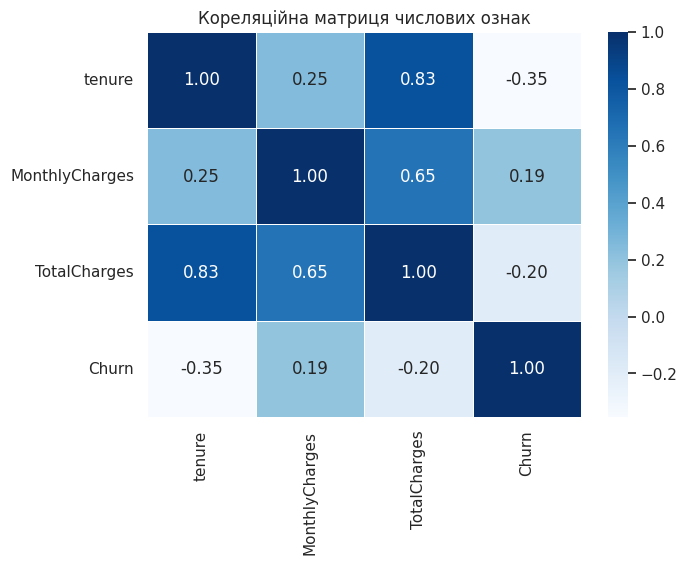

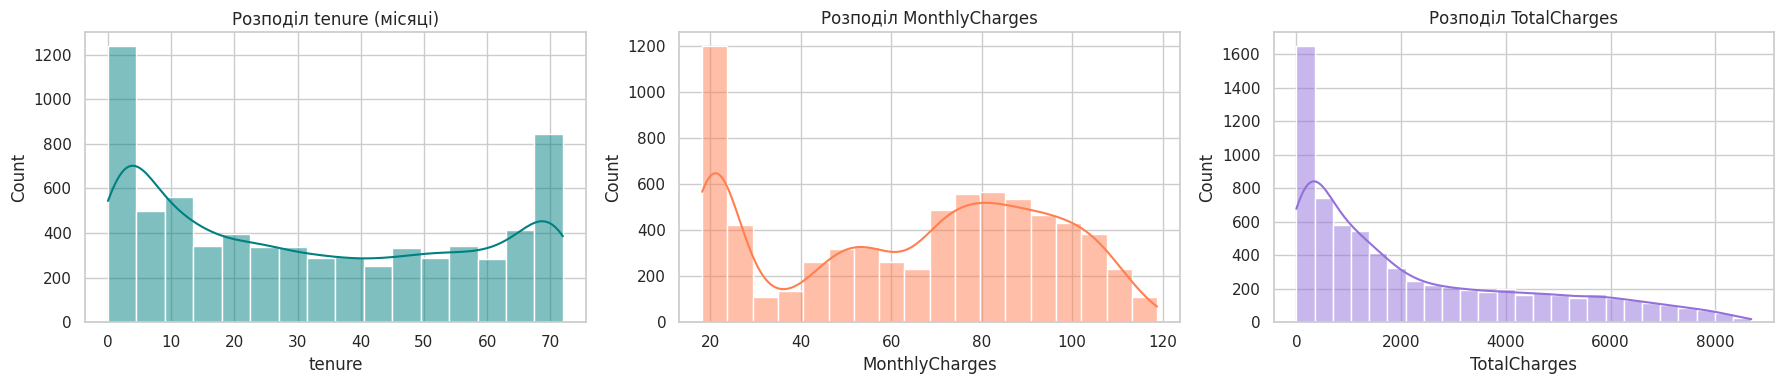

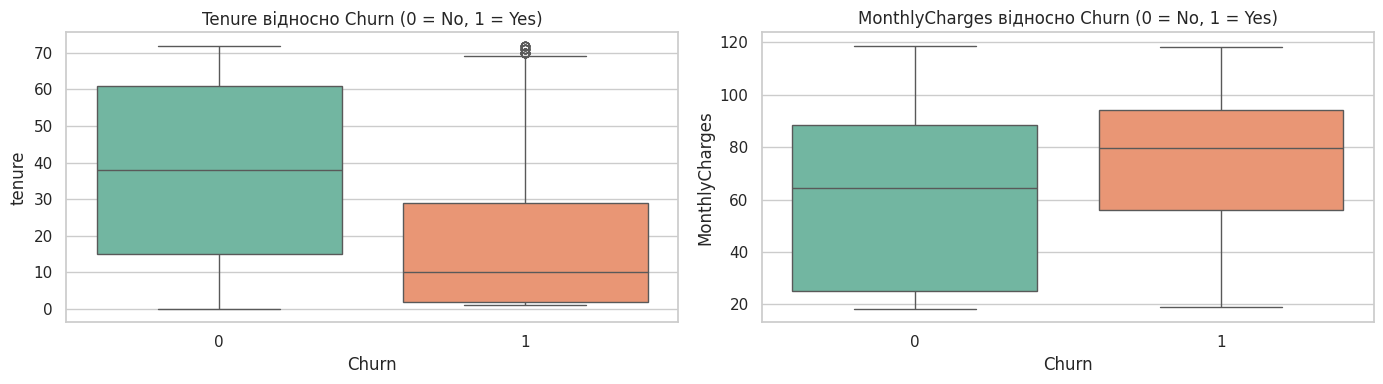

In [ ]:
# 1. Heatmap кореляцій
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Кореляційна матриця числових ознак')
plt.show()

# 2. Гістограми розподілу
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['tenure'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Розподіл tenure (місяці)')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Розподіл MonthlyCharges')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='mediumpurple')
axes[2].set_title('Розподіл TotalCharges')
plt.tight_layout()
plt.show()

# 3. Boxplot відносно Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure відносно Churn (0 = No, 1 = Yes)')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('MonthlyCharges відносно Churn (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

### Висновки з EDA:

1. **Кореляція:** Між `tenure` (тривалістю користування) та `TotalCharges` (загальною сумою оплат) спостерігається сильна додатня лінійна кореляція (0.83), що закономірно — старі клієнти накопичують більше витрат.

2. **Розподіл ознак:**
   - Значна кількість клієнтів є новими (`tenure` < 5 місяців), після чого графік стабілізується.
   - Розподіл `MonthlyCharges` має два піки: дешевий базовий тариф (~20 USD) та дорожчі пакети з додатковими сервісами (70–90 USD).

3. **Зв'язок із відтоком (Churn):**
   - Клієнти, які відмовляються від послуг (`Churn = 1`), мають суттєво менший `tenure` (медіана близько 10 місяців проти 38 місяців у лояльних клієнтів).
   - Щомісячний чек (`MonthlyCharges`) у клієнтів з відтоку помітно вищий (медіана близько 80 USD проти 65 USD).

## 4. Підготовка даних: Train/Test Split та Масштабування

In [ ]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Розбиття на train/test (80/20) зі збереженням балансу класів (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабування ознак для алгоритмів, чутливих до відстаней (kNN, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (5634, 30), X_test shape: (1409, 30)


## 5 та 6. Навчання моделей та підбір гіперпараметрів (GridSearchCV)
Навчаємо 5 класифікаторів:
1. kNN (з підбором `n_neighbors`)
2. Decision Tree
3. SVM (з підбором `C` та `gamma`)
4. Random Forest
5. AdaBoost

In [ ]:
# 1. kNN з пошуком кращого k
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
print(f"Оптимальний k для kNN: {knn_grid.best_params_['n_neighbors']}")

# 2. Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 3. SVM з підбором C та gamma
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01]}
svm_grid = GridSearchCV(SVC(random_state=42), svm_params, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_
print(f"Оптимальні параметри для SVM: {svm_grid.best_params_}")

# 4. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 5. AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

Оптимальний k для kNN: 15
Оптимальні параметри для SVM: {'C': 10, 'gamma': 0.01}


AdaBoostClassifier(n_estimators=100, random_state=42)

## 7. Порівняння та оцінювання моделей


==================== kNN (tuned) ====================
              precision    recall  f1-score   support

           0     0.8370    0.8531    0.8450      1035
           1     0.5706    0.5401    0.5549       374

    accuracy                         0.7700      1409
   macro avg     0.7038    0.6966    0.7000      1409
weighted avg     0.7663    0.7700    0.7680      1409


==================== Decision Tree ====================
              precision    recall  f1-score   support

           0     0.8421    0.8860    0.8635      1035
           1     0.6312    0.5401    0.5821       374

    accuracy                         0.7942      1409
   macro avg     0.7367    0.7130    0.7228      1409
weighted avg     0.7861    0.7942    0.7888      1409


==================== SVM (tuned) ====================
              precision    recall  f1-score   support

           0     0.8318    0.8937    0.8617      1035
           1     0.6296    0.5000    0.5574       374

    accuracy   

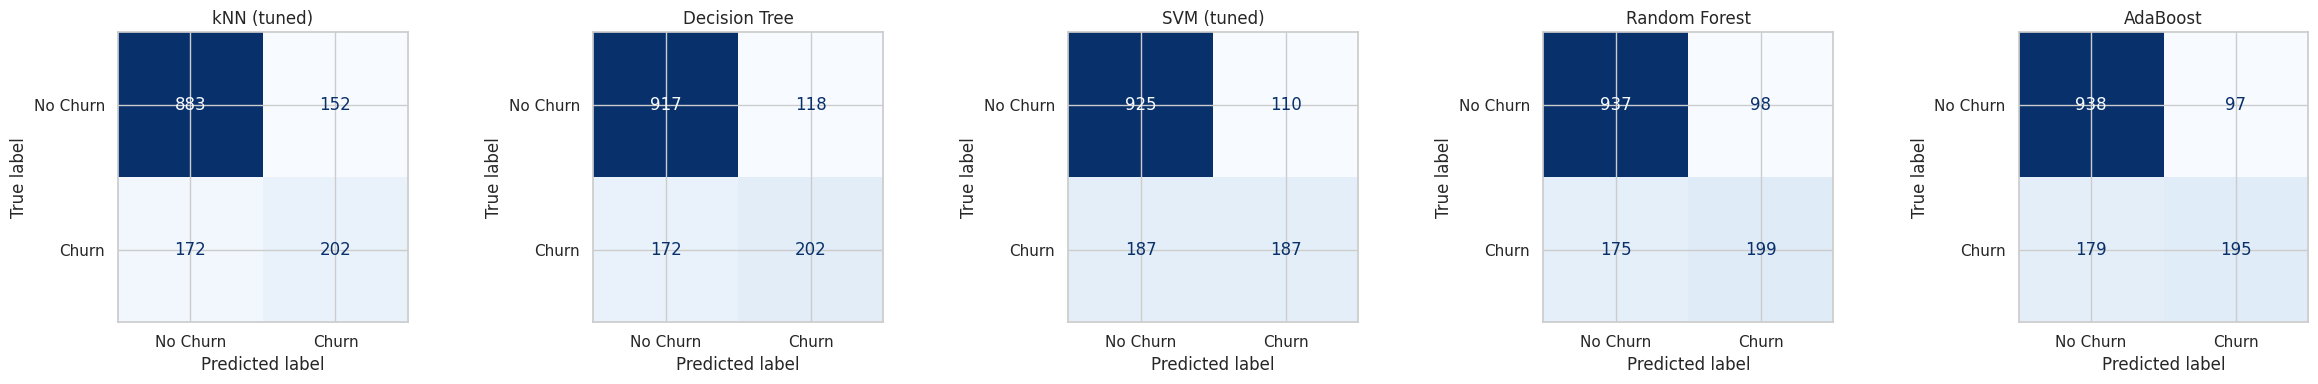

In [ ]:
models = {
    'kNN (tuned)': (best_knn, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'SVM (tuned)': (best_svm, X_test_scaled),
    'Random Forest': (rf_model, X_test),
    'AdaBoost': (ada_model, X_test)
}

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
idx = 0

for name, (model, data_test) in models.items():
    y_pred = model.predict(data_test)

    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)
    idx += 1

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, (model, data_test) in models.items():
    preds = model.predict(data_test)
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (class 1)': round(precision_score(y_test, preds), 4),
        'Recall (class 1)': round(recall_score(y_test, preds), 4),
        'F1-score (class 1)': round(f1_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-score (class 1)', ascending=False)
display(results_df)

,Model,Accuracy,Precision (class 1),Recall (class 1),F1-score (class 1)
3,Random Forest,0.8062,0.6700,0.5321,0.5931
4,AdaBoost,0.8041,0.6678,0.5214,0.5856
1,Decision Tree,0.7942,0.6312,0.5401,0.5821
2,SVM (tuned),0.7892,0.6296,0.5000,0.5574
0,kNN (tuned),0.7700,0.5706,0.5401,0.5549


### 7. Підсумковий висновок та оцінка моделей

**Баланс класів та вибір метрики:**
У датасеті є помітний перекіс класів: майже 73.5% клієнтів залишилися, а пішли лише 26.5%. Через це загальна точність (Accuracy) є оманливою — якби класифікатор просто кожному клієнту ставив «0» (лояльний), він уже формально мав би ~73.5% точності, проте не виявив би жодної втрати. Тому головна увага зосереджена на метриках **F1-score** та **Recall** саме для класу `1` (Churn), адже бізнесу важливо вчасно помітити потенційний відтік.

**Аналіз результатів:**
- **kNN (k=15):** показав найслабший результат (Accuracy 0.7700, F1 0.5549). Після кодування категорій утворилося 30 числових колонок. Через «прокляття розмірності» у просторі такої вимірності відстані між точками згладжуються, і алгоритм починає плутатися в сусідах.
- **SVM (C=10, gamma=0.01):** видав непоганий Precision (0.6296), але показав слабкий Recall (0.5000) — тобто пропустив рівно половину тих, хто розірвав контракт (187 із 374). Через чисельну перевагу класу «0» розділова гіперплощина зсунулася, і модель стала надто обережно роздавати одиниці.
- **Decision Tree (max_depth=5):** показало цілком збалансований базовий результат (Accuracy 0.7942, F1 0.5821), проте одиночні дерева легко піддаються випадковим шумам у вибірці.
- **AdaBoost:** послідовне виправлення помилок на бустингу покращило якість майже до рівня лідера (Accuracy 0.8041, F1 0.5856).

**Найкраща модель — Random Forest:**
Ансамбль випадкового лісу виявився переможцем за всіма ключовими показниками (Accuracy = 0.8062, Precision = 0.6700, F1 = 0.5931).

**Чому саме він найкраще підходить для цих даних:**
- **Практична користь для бізнесу:** модель має найвищий показник Precision (67%). Тобто з трьох людей, яких модель назве кандидатами на відтік, двоє дійсно збираються піти. Компанія витрачатиме бюджет на бонуси чи знижки саме на реальних «втікачів», а не даремно роздаватиме знижки тим, хто і так би залишився.
- **Стійкість алгоритму:** дерева рішень від природи не бояться сильної кореляції між `tenure` та `TotalCharges`, а об'єднання 100 дерев у ліс чудово впоралося з великою кількістю дрібних бінарних колонок після One-Hot Encoding без перенавчання.